# 03 Analyze — Delivery Patterns, Risk Prioritisation, and Weekly Workload

This notebook  
- organise the processed data   
- performe calculations  
- aggregate results  
- identify trends and relationships  
- summarise how the findings answer the business questions.  
  
This notebook addresses the following business problem:  
  
**How can historical order data be used to understand late-delivery patterns, identify orders that may require early attention, and prioritise limited review capacity?**  
  
**Inputs:**  
     
- `order_level_analysis_ready.csv` — one eligible order per row;  
- `weekly_analysis_ready.csv` — one complete Monday-to-Sunday week per row.  
  
**tools:**  
  
- **DuchDB SQL** for selected data extraction, transformation, and aggregation;  
- **Python with pandas and NumPy** for analysis, calculations, capacity simulation, and forecasting;  
- **scikit-learn** for one interpretable logistic-regression risk model;  
- **Matplotlib** for decision-relevant visualisations.  
  
**Deliverables:**

1. **Historical delivery evidence for AQ1 and AQ2**

   * overall eligible-order count, late-order count, and late-delivery rate;
   * monthly and complete-week delivery trends;
   * selected operational-segment comparisons with exposure counts;
   * selected order-profile comparisons.

2. **A simple time-aware risk ranking for AQ3**

   * a leakage-safe temporal train-test split;
   * a non-informative baseline and one interpretable logistic-regression model;
   * Average Precision, ROC-AUC, and a precision–recall curve;
   * risk scores and ranks for held-out test-period orders.

3. **Limited-capacity review evidence for AQ4**

   * retrospective review simulations at 5%, 10%, and 20% of eligible held-out test-period orders;
   * late-order recall, review precision, and lift over baseline at each capacity level;
   * a preferred 10% order-level review queue.

4. **An AQ1–AQ4 analysis summary**

   * principal evidence and a consolidated answer for each analytical question;
   * decision relevance, assumptions, and limitations;
   * selected final tables and figures prepared for the Share phase.
  

**Analysis boundary:**  

This notebook does not:  
- use post-order information as predictive input  
- establish causal relationships  
- represent the proxy-data findings as evidence about any real organisation.

## 1. Confirm and organise the analysis inputs  
  
This section receives the validated outputs from Notebook 02, confirms that they can support AQ1–AQ4, and defines how each field may be used before any analytical result is calculated.  
  
This section has three purposes:  
  
1. load and minimally validate the two Process-stage outputs (`order_level_analysis_ready.csv` and `weekly_analysis_ready.csv`);  
2. map AQ1–AQ4 to the required datasets, fields, methods, and metrics; and  
3. separate predictive fields from identifiers, outcomes, and post-order information that could cause data leakage.  

### 1.1 Load and validate the Process outputs  
  
This subsection performs a minimal handoff check by:  
  
- confirming that both files exist in `data/processed`;  
- loading the documented date fields as datetime values;  
- confirming the expected columns and analytical grains;  
- checking the uniqueness of `Order Id` and `Week Start`;  
- confirming that the late-delivery target is complete and binary; and  
- checking that the weekly dates are consecutive Mondays.  

**Load the Process outputs**

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display


# Identify the project root.
# The notebook may run from either the project root or the notebooks folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


# Define the processed-data paths.
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ORDER_PATH = PROCESSED_DIR / "order_level_analysis_ready.csv"
WEEKLY_PATH = PROCESSED_DIR / "weekly_analysis_ready.csv"


# Confirm that both Process outputs are available.
required_input_files = [ORDER_PATH, WEEKLY_PATH]

missing_input_files = [
    path.name
    for path in required_input_files
    if not path.exists()
]

if missing_input_files:
    raise FileNotFoundError(
        "Required Process output(s) not found in data/processed: "
        + ", ".join(missing_input_files)
    )


# Load the order-level dataset and parse its date fields.
order_df = pd.read_csv(
    ORDER_PATH,
    parse_dates=[
        "order date (DateOrders)",
        "shipping date (DateOrders)",
    ],
)


# Load the complete-week dataset and parse the week-start field.
weekly_df = pd.read_csv(
    WEEKLY_PATH,
    parse_dates=["Week Start"],
)


print("Process outputs loaded successfully.")

Process outputs loaded successfully.


**Review the loaded inputs**

In [2]:
# Summarise the loaded Process outputs.
input_overview = pd.DataFrame([
    {
        "Dataset": "Order-level",
        "Filename": ORDER_PATH.name,
        "Analytical grain": "One eligible order per row",
        "Rows": order_df.shape[0],
        "Columns": order_df.shape[1],
        "Date start": order_df["order date (DateOrders)"].min().date(),
        "Date end": order_df["order date (DateOrders)"].max().date(),
    },
    {
        "Dataset": "Complete-week",
        "Filename": WEEKLY_PATH.name,
        "Analytical grain": "One complete Monday-to-Sunday week per row",
        "Rows": weekly_df.shape[0],
        "Columns": weekly_df.shape[1],
        "Date start": weekly_df["Week Start"].min().date(),
        "Date end": (
            weekly_df["Week Start"].max()
            + pd.Timedelta(days=6)
        ).date(),
    },
])

display(input_overview)


# Display small previews of the loaded datasets.
display(order_df.head(3))
display(weekly_df.head(3))

,Dataset,Filename,Analytical grain,Rows,Columns,Date start,Date end
0,Order-level,order_level_analysis_ready.csv,One eligible order per row,62897,15,2015-01-01,2018-01-31
1,Complete-week,weekly_analysis_ready.csv,One complete Monday-to-Sunday week per row,160,3,2015-01-05,2018-01-28


,Order Id,order date (DateOrders),shipping date (DateOrders),Late_delivery_risk,Shipping Mode,Type,Customer Segment,Market,Order Region,Days for shipment (scheduled),Days for shipping (real),Order Item Count,Product Count,Order Quantity,Order Value
0,1,2015-01-01 00:00:00,2015-01-03 00:00:00,0,Standard Class,CASH,Consumer,LATAM,Central America,4,2,1,1,1,239.979996
1,2,2015-01-01 00:21:00,2015-01-04 00:21:00,0,Standard Class,PAYMENT,Consumer,LATAM,South America,4,3,3,3,7,529.380005
2,4,2015-01-01 01:03:00,2015-01-06 01:03:00,1,Standard Class,CASH,Home Office,LATAM,South America,4,5,4,4,14,620.870014


,Week Start,Eligible Order Count,Late Order Count
0,2015-01-05,391,216
1,2015-01-12,380,216
2,2015-01-19,378,213


**Key observations**

- The order-level input contains **62,897 rows and 15 columns**, with one unique eligible order per row.
- The complete-week input contains **160 rows and 3 columns**, with one consecutive Monday-to-Sunday week per row.
- `Order Id` and `Week Start` are complete and unique at their respective analytical grains.
- The required fields contain no unresolved missing values.
- `Late_delivery_risk` is a complete binary target containing only `0` and `1`.
- All complete-week records begin on a Monday, and no calendar gaps occur between the observed weeks.
- All minimum handoff checks passed, so both Process outputs are accepted for the Analyze phase.

These results confirm input readiness only. Delivery performance, risk relationships, model performance, capacity outcomes, and forecasts have not yet been calculated in this notebook.

## 1.2 Map AQ1–AQ4 to inputs, methods, metrics, and evidence

The Ask phase defined four analytical questions that must remain traceable throughout the Analyze phase. The table below maps each question to its supported decision, primary input, analytical method, predefined metrics, and expected evidence.

This mapping defines the analysis plan only. The analyses are completed in Sections 2–4 and summarised in Section 5.

| Question                       | Analytical question                                                                                                                                                                                                | Decision | Primary input                          | Method and tool                                                   | Metrics | Planned evidence                                                                                |
| ------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------: | -------------------------------------- | ----------------------------------------------------------------- | ------- | ----------------------------------------------------------------------------------------------- |
| **AQ1 — Delivery performance** | Over the validated historical period, what are the order-level late-order count and late-delivery rate, and how do they change by week or month and across selected operational segments?                          |       D1 | Order-level and complete-week datasets | DuckDB SQL and pandas aggregations                                | M01–M03 | Overall, monthly, weekly, and selected segment summaries                                        |
| **AQ2 — Associated factors**   | Which attributes known at order creation are associated with higher or lower late-delivery rates, after accounting for exposure counts and without making causal claims?                                           |       D1 | Order-level dataset                    | DuckDB SQL segment aggregation and pandas profile comparison      | M01–M03 | Exposure counts, late-order counts, late-delivery rates, and selected order-profile comparisons |
| **AQ3 — Risk ranking**         | Using only information available at order creation, can a time-aware model rank orders in a later held-out test period by late-delivery risk more effectively than a non-informative baseline?                     |       D2 | Order-level dataset                    | Temporal split, non-informative baseline, and logistic regression | M04–M07 | Model evaluation, calibration evidence, and held-out test-period risk scores and ranks          |
| **AQ4 — Prioritisation**       | When review capacity is limited to 5%, 10%, or 20% of eligible orders, which orders should be reviewed first, and what late-order recall, precision, and lift would the queue achieve in the held-out test period? |       D3 | AQ3 scored held-out test-period orders | Risk ranking and capacity simulation in pandas                    | M08–M10 | Capacity comparison table and internal order-level review queue                                 |

**Analytical dependencies**

* AQ1 and AQ2 use the validated historical Process outputs directly.
* The complete-week dataset is used in AQ1 to describe weekly delivery patterns; it is not used for workload forecasting.
* AQ3 applies a temporal train-test split and produces risk scores and ranks for the held-out test-period orders.
* AQ4 reuses the AQ3 risk ranking to simulate different review-capacity levels and does not train another model.
* Changing the review-capacity share changes the number of orders selected for review, but it does not change the fitted risk model or the underlying risk scores.


## 2. Describe historical delivery patterns — AQ1 and AQ2  
  
This section    
- aggregate data    
- perform calculations    
- identify trends and relationships    
- explain how the resulting evidence helps answer the business questions.  
  
This section answers two analytical questions:  
  
- **AQ1 — Delivery performance:** Over the validated historical period, what are the order-level late-order count and late-delivery rate, and how do they change by week or month and by selected operational segments?  
- **AQ2 — Associated factors:** Which attributes known at order creation are associated with higher or lower late-delivery rates, after accounting for exposure counts and without making causal claims?  
  
The analysis will:  
  
1. calculate the overall eligible-order count, late-order count, and late-delivery rate;  
2. examine delivery performance by month and complete week;  
3. compare selected operational segments using order counts and late-delivery rates; and  
4. compare selected order profiles between late and on-time orders.  
  
Selected aggregations will be performed in **PostgreSQL**, while **pandas** will support additional comparisons and result preparation. Only a small number of decision-relevant visualisations will be created.  
  
**Interpretation rules**  
  
- Order counts must be reported alongside late-delivery rates so that small groups are not interpreted without their exposure.
- Observed differences are described as patterns or associations, not evidence of causation.
- Only fields that are available at order creation and have clear business meaning are used in AQ2.
- Post-order fields may support retrospective description but are not treated as predictive risk factors.
- This section produces historical descriptive and diagnostic evidence only; risk scores, capacity results, and forecasts are produced in later sections.

### 2.1 AQ1 - Calculate overall delivery KPIs  
  
AQ1 begins by establishing the overall level of historical delivery performance before examining changes over time or differences between operational segments.  
  
This subsection calculates the three business metrics defined in Notebook 00:  
  
| Metric ID | Metric | Calculation |
|---|---|---|
| **M01** | Eligible order count | Number of eligible orders in the validated order-level dataset |
| **M02** | Late order count | Number of eligible orders where `Late_delivery_risk = 1` |
| **M03** | Late-delivery rate | Late order count divided by eligible order count |
  
Because the Process output contains one eligible order per row and a binary late-delivery target:  
  
- `COUNT(*)` returns the eligible order count;  
- `SUM(late_delivery_risk)` returns the late order count; and  
- `AVG(late_delivery_risk)` returns the late-delivery rate.  
  
DuckDB performs the calculation. pandas receives the SQL result for validation, display, and later export; it does not recalculate the same KPIs.  

**Create DuckDB view**

In [3]:
import duckdb


# Create an in-memory DuckDB connection.
# The database is rebuilt automatically when the notebook is rerun.
duckdb_connection = duckdb.connect(database=":memory:")


# Register the validated order-level DataFrame as a SQL query source.
duckdb_connection.register(
    "order_source",
    order_df,
)


# Create a SQL-friendly analytical view.
# Post-order fields are excluded because they are not required for AQ1–AQ2.
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW orders_analysis AS

    SELECT
        "Order Id" AS order_id,
        "order date (DateOrders)" AS order_date,
        "Late_delivery_risk" AS late_delivery_risk,
        "Shipping Mode" AS shipping_mode,
        "Type" AS transaction_type,
        "Customer Segment" AS customer_segment,
        "Market" AS market,
        "Order Region" AS order_region,
        "Days for shipment (scheduled)" AS scheduled_shipping_days,
        "Order Item Count" AS order_item_count,
        "Product Count" AS product_count,
        "Order Quantity" AS order_quantity,
        "Order Value" AS order_value

    FROM order_source
    """
)

# Create the analytical view
orders_view_preview = duckdb_connection.sql(
    """
    SELECT *
    FROM orders_analysis
    ORDER BY order_date, order_id
    LIMIT 5
    """
).df()

display(orders_view_preview)

# Inspect the fields and data types in the view
orders_view_schema = duckdb_connection.sql(
    """
    DESCRIBE orders_analysis
    """
).df()

display(orders_view_schema)


,order_id,order_date,late_delivery_risk,shipping_mode,transaction_type,customer_segment,market,order_region,scheduled_shipping_days,order_item_count,product_count,order_quantity,order_value
0,1,2015-01-01 00:00:00,0,Standard Class,CASH,Consumer,LATAM,Central America,4,1,1,1,239.979996
1,2,2015-01-01 00:21:00,0,Standard Class,PAYMENT,Consumer,LATAM,South America,4,3,3,7,529.380005
2,4,2015-01-01 01:03:00,1,Standard Class,CASH,Home Office,LATAM,South America,4,4,4,14,620.870014
3,5,2015-01-01 01:24:00,1,Standard Class,DEBIT,Consumer,LATAM,South America,4,5,4,10,987.070007
4,7,2015-01-01 02:06:00,1,Second Class,DEBIT,Consumer,LATAM,South America,2,3,3,7,525.520004


,column_name,column_type,null,key,default,extra
0,order_id,BIGINT,YES,None,None,None
1,order_date,TIMESTAMP,YES,None,None,None
2,late_delivery_risk,BIGINT,YES,None,None,None
3,shipping_mode,VARCHAR,YES,None,None,None
4,transaction_type,VARCHAR,YES,None,None,None
5,customer_segment,VARCHAR,YES,None,None,None
6,market,VARCHAR,YES,None,None,None
7,order_region,VARCHAR,YES,None,None,None
8,scheduled_shipping_days,BIGINT,YES,None,None,None
9,order_item_count,BIGINT,YES,None,None,None


**Calculate AQ1 KPIs**

In [4]:
# Calculate the overall AQ1 metrics in DuckDB SQL.
overall_kpis = duckdb_connection.sql(
    """
    SELECT
        COUNT(*) AS eligible_order_count,
        SUM(late_delivery_risk) AS late_order_count,
        AVG(
            CAST(late_delivery_risk AS DOUBLE)
        ) AS late_delivery_rate

    FROM orders_analysis
    """
).df()

**Display Overall results of Mesures 01 - 03**

In [5]:
eligible_order_count = int(
    overall_kpis.loc[0, "eligible_order_count"]
)

late_order_count = int(
    overall_kpis.loc[0, "late_order_count"]
)

late_delivery_rate = float(
    overall_kpis.loc[0, "late_delivery_rate"]
)


# Confirm that the SQL view received the full Process output.
assert overall_kpis.shape == (1, 3)
assert eligible_order_count == len(order_df)
assert 0 <= late_order_count <= eligible_order_count
assert 0 <= late_delivery_rate <= 1


# Format the SQL result as a readable metric table.
overall_kpi_display = pd.DataFrame([
    {
        "Metric ID": "M01",
        "Metric": "Eligible order count",
        "Value": f"{eligible_order_count:,}",
    },
    {
        "Metric ID": "M02",
        "Metric": "Late order count",
        "Value": f"{late_order_count:,}",
    },
    {
        "Metric ID": "M03",
        "Metric": "Late-delivery rate",
        "Value": f"{late_delivery_rate:.2%}",
    },
])

display(overall_kpi_display)

,Metric ID,Metric,Value
0,M01,Eligible order count,"62,897"
1,M02,Late order count,"36,048"
2,M03,Late-delivery rate,57.31%


**Key observations**

- The validated historical dataset contains **62,897 eligible orders**.
- Of these orders, **36,048 were classified as late deliveries**.
- The overall late-delivery rate is **57.31%**.
- Late deliveries represent the majority outcome in this processed dataset rather than a rare class.

The overall late-delivery rate provides the historical reference point for the monthly, complete-week, and segment comparisons that follow.

These results describe the frequency of late delivery in the supplied proxy dataset. They do not explain why deliveries were late and do not establish a causal relationship.

### 2.2 AQ1 - Analyse monthly and complete-week trends

AQ1 also asks how late-order counts and late-delivery rates change over time. This subsection examines delivery performance at two complementary time grains:

- **calendar month**, aggregated from the validated order-level data using DuckDB SQL; and
- **complete Monday-to-Sunday week**, using the weekly dataset already created and validated in Notebook 02.

For each period, the analysis reports:

| Measure | Definition |
|---|---|
| Eligible order count | Number of eligible orders within the period |
| Late order count | Number of eligible orders classified as late |
| Late-delivery rate | Late order count divided by eligible order count |

The monthly view provides a readable summary of longer-term movement. The complete-week view preserves shorter-term variation while excluding partial first and last boundary weeks.

The weekly table is not rebuilt from `order_df` because that aggregation was already completed in Notebook 02. No forecasting is performed in this subsection; future workload forecasting is reserved for Section 5.

**Calculate the monthly measures**

In [6]:
# Aggregate the validated order-level data by calendar month in DuckDB SQL.
monthly_delivery_trend = duckdb_connection.sql(
    """
    SELECT
        DATE_TRUNC(
            'month',
            order_date
        ) AS order_month,
        COUNT(*) AS eligible_order_count,
        SUM(late_delivery_risk) AS late_order_count,
        AVG(
            CAST(late_delivery_risk AS DOUBLE)
        ) AS late_delivery_rate

    FROM orders_analysis

    GROUP BY order_month
    ORDER BY order_month
    """
).df()

print(monthly_delivery_trend)

   order_month  eligible_order_count  late_order_count  late_delivery_rate
0   2015-01-01                  1713             963.0            0.562172
1   2015-02-01                  1505             871.0            0.578738
2   2015-03-01                  1702             978.0            0.574618
3   2015-04-01                  1639             927.0            0.565589
4   2015-05-01                  1684             969.0            0.575416
5   2015-06-01                  1651             941.0            0.569958
6   2015-07-01                  1704             963.0            0.565141
7   2015-08-01                  1678             966.0            0.575685
8   2015-09-01                  1634             951.0            0.582007
9   2015-10-01                  1696             973.0            0.573703
10  2015-11-01                  1658             941.0            0.567551
11  2015-12-01                  1731             988.0            0.570768
12  2016-01-01           

**Calculate the complete-weekly-level measures**  

In [7]:
# Register the validated complete-week DataFrame as a DuckDB query source.
duckdb_connection.register(
    "weekly_source",
    weekly_df,
)


# Prepare the validated complete-week measures using DuckDB SQL.
weekly_delivery_trend = duckdb_connection.sql(
    """
    SELECT
        CAST(
            "Week Start" AS TIMESTAMP
        ) AS week_start,

        CAST(
            "Eligible Order Count" AS BIGINT
        ) AS eligible_order_count,

        CAST(
            "Late Order Count" AS BIGINT
        ) AS late_order_count,

        CAST(
            "Late Order Count" AS DOUBLE
        )
        /
        NULLIF(
            CAST(
                "Eligible Order Count" AS DOUBLE
            ),
            0
        ) AS late_delivery_rate

    FROM weekly_source

    ORDER BY week_start
    """
).df()

print(weekly_delivery_trend)

    week_start  eligible_order_count  late_order_count  late_delivery_rate
0   2015-01-05                   391               216            0.552430
1   2015-01-12                   380               216            0.568421
2   2015-01-19                   378               213            0.563492
3   2015-01-26                   387               223            0.576227
4   2015-02-02                   380               229            0.602632
..         ...                   ...               ...                 ...
155 2017-12-25                   455               260            0.571429
156 2018-01-01                   460               276            0.600000
157 2018-01-08                   455               278            0.610989
158 2018-01-15                   464               260            0.560345
159 2018-01-22                   463               272            0.587473

[160 rows x 4 columns]


**Visualse the month-level delivery trend**

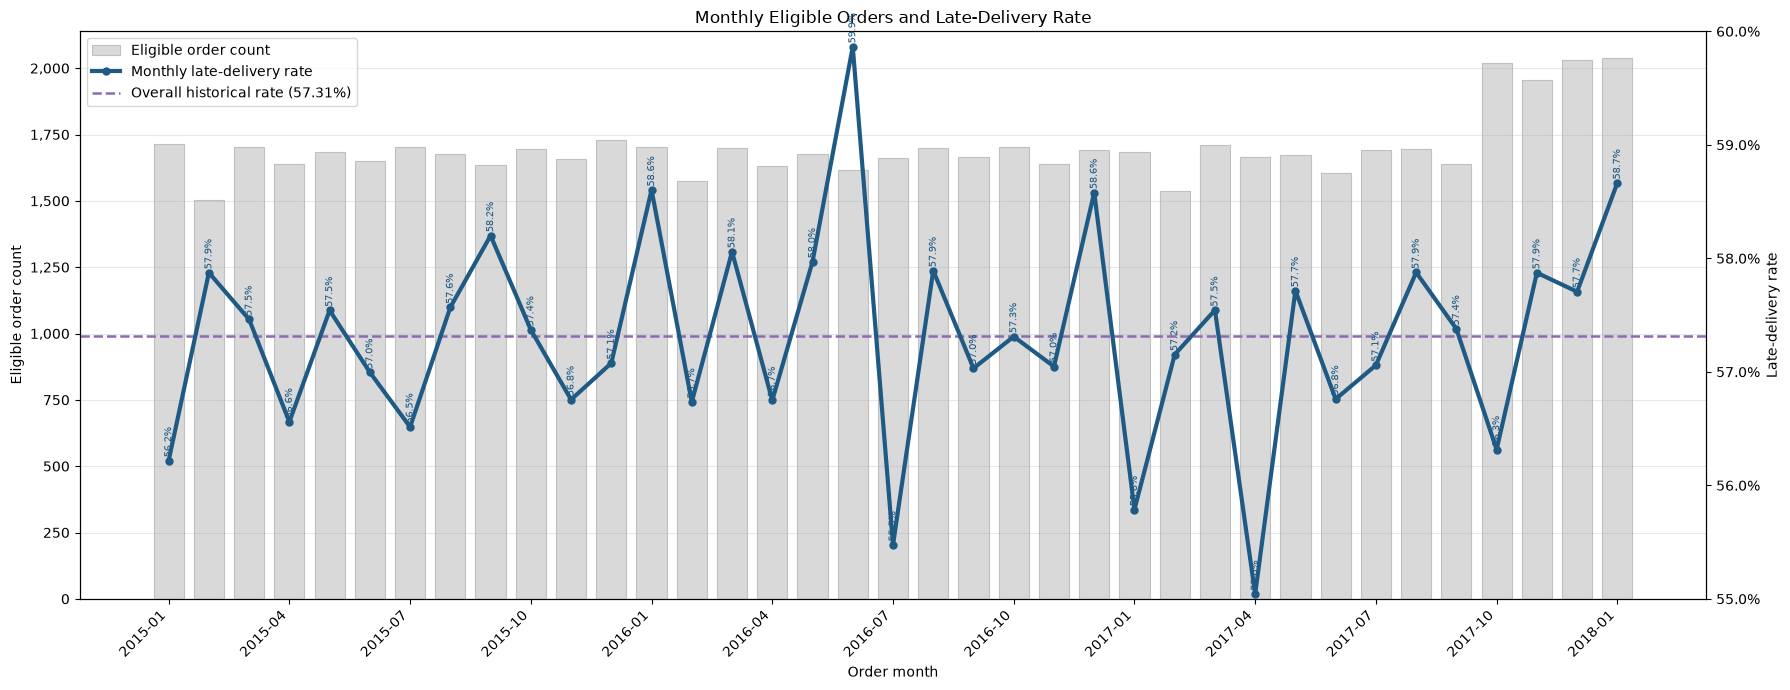

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (
    PercentFormatter,
    StrMethodFormatter,
)


# Prepare the monthly chart data.
monthly_chart_data = (
    monthly_delivery_trend
    .sort_values("order_month")
    .reset_index(drop=True)
    .copy()
)

monthly_chart_data["month_label"] = (
    monthly_chart_data["order_month"]
    .dt.strftime("%Y-%m")
)

x_positions = np.arange(
    len(monthly_chart_data)
)


# Create the eligible-order count axis.
monthly_trend_fig, ax_count = plt.subplots(
    figsize=(18, 7)
)


# Plot monthly eligible-order counts with a light, low-saturation color.
ax_count.bar(
    x_positions,
    monthly_chart_data["eligible_order_count"],
    width=0.75,
    color="#d9d9d9",      # light grey
    edgecolor="#c0c0c0",
    linewidth=0.8,
    label="Eligible order count",
)


# Create the late-delivery-rate axis.
ax_rate = ax_count.twinx()


# Plot the monthly late-delivery rate with a stronger and wider line.
ax_rate.plot(
    x_positions,
    monthly_chart_data["late_delivery_rate"],
    marker="o",
    markersize=5,
    linewidth=3.0,
    color="#1f5a85",          # darker and more distinct blue
    label="Monthly late-delivery rate",
    zorder=4,
)


# Add the overall historical rate from Section 2.1.
ax_rate.axhline(
    late_delivery_rate,
    linestyle="--",
    linewidth=1.8,
    color="#8c6bb1",
    label=(
        "Overall historical rate "
        f"({late_delivery_rate:.2%})"
    ),
)


# Label each monthly rate.
for row_number, row in monthly_chart_data.iterrows():

    ax_rate.text(
        row_number,
        row["late_delivery_rate"] + 0.0003,
        f"{row['late_delivery_rate']:.1%}",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=7,
        color="#1f5a85",
    )


# Show every third month on the x-axis.
selected_positions = x_positions[::3]

ax_count.set_xticks(
    selected_positions
)

ax_count.set_xticklabels(
    monthly_chart_data["month_label"].iloc[::3],
    rotation=45,
    ha="right",
)


# Format the eligible-order count axis.
ax_count.set_title(
    "Monthly Eligible Orders and Late-Delivery Rate"
)

ax_count.set_xlabel(
    "Order month"
)

ax_count.set_ylabel(
    "Eligible order count"
)

ax_count.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)


# Format the late-delivery-rate axis.
ax_rate.set_ylabel(
    "Late-delivery rate"
)

ax_rate.set_ylim(
    0.55,
    0.60,
)

ax_rate.set_yticks(
    np.arange(
        0.55,
        0.601,
        0.01,
    )
)

ax_rate.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


# Combine the two legends.
count_handles, count_labels = (
    ax_count.get_legend_handles_labels()
)

rate_handles, rate_labels = (
    ax_rate.get_legend_handles_labels()
)

ax_count.legend(
    count_handles + rate_handles,
    count_labels + rate_labels,
    loc="upper left",
)


ax_count.grid(
    axis="y",
    alpha=0.3,
)

monthly_trend_fig.tight_layout()

plt.show()

**Key observations - Monthly**

- Monthly eligible-order volume remains relatively stable across most of the historical period, with only moderate variation between months.
- Monthly late-delivery rates fluctuate within a relatively narrow range, from approximately **55.04%** to **59.86%**.
- The monthly rate generally moves around the overall historical late-delivery rate of **57.31%** rather than showing a clear sustained upward or downward trend.
- Some months move noticeably above or below the historical reference line, but these differences are temporary rather than persistent across the full period.
- Because monthly order volumes are broadly similar, the observed changes in late-delivery rate are unlikely to be explained by large differences in monthly exposure alone.

These patterns are descriptive. They show how delivery performance varied over time but do not explain the causes of the monthly differences.

**Visualise the complete-week-level delivery trend**

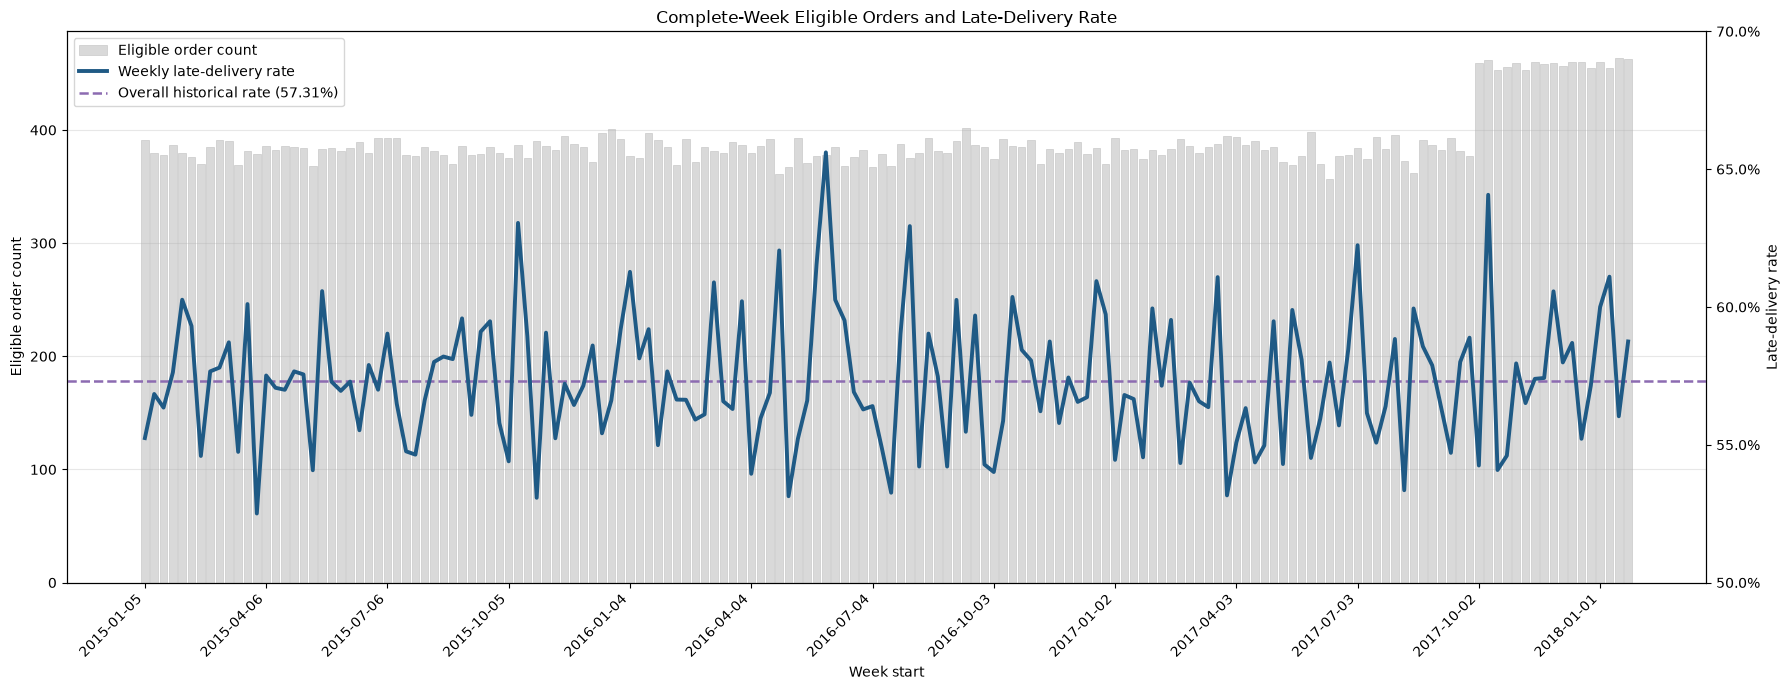

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (
    PercentFormatter,
    StrMethodFormatter,
)


# Prepare the complete-week chart data.
weekly_chart_data = (
    weekly_delivery_trend
    .sort_values("week_start")
    .reset_index(drop=True)
    .copy()
)

weekly_chart_data["week_label"] = (
    weekly_chart_data["week_start"]
    .dt.strftime("%Y-%m-%d")
)

x_positions = np.arange(
    len(weekly_chart_data)
)


# Create the eligible-order count axis.
weekly_trend_fig, ax_count = plt.subplots(
    figsize=(18, 7)
)


# Plot weekly eligible-order counts in light grey.
ax_count.bar(
    x_positions,
    weekly_chart_data["eligible_order_count"],
    width=0.8,
    color="#d9d9d9",
    edgecolor="#c0c0c0",
    linewidth=0.4,
    label="Eligible order count",
)


# Create the late-delivery-rate axis.
ax_rate = ax_count.twinx()


# Plot the weekly late-delivery rate.
ax_rate.plot(
    x_positions,
    weekly_chart_data["late_delivery_rate"],
    linewidth=2.8,
    color="#1f5a85",
    label="Weekly late-delivery rate",
    zorder=4,
)


# Add the overall historical late-delivery-rate reference line.
ax_rate.axhline(
    late_delivery_rate,
    linestyle="--",
    linewidth=1.8,
    color="#8c6bb1",
    label=(
        "Overall historical rate "
        f"({late_delivery_rate:.2%})"
    ),
)


# Show selected week labels only.
tick_interval = 13

selected_positions = x_positions[::tick_interval]

ax_count.set_xticks(
    selected_positions
)

ax_count.set_xticklabels(
    weekly_chart_data[
        "week_label"
    ].iloc[::tick_interval],
    rotation=45,
    ha="right",
)


# Format the eligible-order count axis.
ax_count.set_title(
    "Complete-Week Eligible Orders and Late-Delivery Rate"
)

ax_count.set_xlabel(
    "Week start"
)

ax_count.set_ylabel(
    "Eligible order count"
)

ax_count.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)


# Format the late-delivery-rate axis.
ax_rate.set_ylabel(
    "Late-delivery rate"
)

ax_rate.set_ylim(
    0.50,
    0.70,
)

ax_rate.set_yticks(
    np.arange(
        0.50,
        0.701,
        0.05,
    )
)

ax_rate.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


# Combine legends from both axes.
count_handles, count_labels = (
    ax_count.get_legend_handles_labels()
)

rate_handles, rate_labels = (
    ax_rate.get_legend_handles_labels()
)

ax_count.legend(
    count_handles + rate_handles,
    count_labels + rate_labels,
    loc="upper left",
)


ax_count.grid(
    axis="y",
    alpha=0.3,
)

weekly_trend_fig.tight_layout()

plt.show()

**Key observations - Weekly**  
  
- Complete-week late-delivery rates show noticeably greater short-term variation than the monthly rates.  
- Across the 160 complete weeks, the late-delivery rate ranges from approximately **52.51%** to **65.61%**.  
- Despite these week-to-week fluctuations, the series generally moves around the overall historical late-delivery rate of **57.31%** rather than showing a clear sustained upward or downward trend.  
- Weekly eligible-order volumes remain broadly stable, so the larger movement in the weekly late-delivery rate is not accompanied by similarly large changes in weekly order volume.  
- The complete-week series contains **62,474 eligible orders**, covering approximately **99.33%** of the full eligible-order history.  
  
The weekly view is useful for identifying short-term variation that is smoothed out in the monthly view. These patterns are descriptive and do not identify the causes of individual weekly changes.

### 2.3 AQ1 - Compare selected operational segments  
   
This part compares grouped results to identify relationships and differences across business-relevant segments.  
  
**Project workflow role:**    
The analysis compares the late-delivery performance across three selected operational segments:  
- `Shipping Mode`  
- `Customer Segment`  
- `Market`  
     
For each segment, the analysis reports:  
  
- eligible-order count;
- late-order count; and
- late-delivery rate.

**Display the late-delivery performance across three segments**

In [10]:
segment_delivery_summary = duckdb_connection.sql(
    """
    SELECT
        'Shipping Mode' AS "Segment",
        shipping_mode AS "Category",
        COUNT(*) AS "Eligible order count",
        SUM(late_delivery_risk) AS "Late order count",
        AVG(CAST(late_delivery_risk AS DOUBLE))
            AS "Late-delivery rate"
    FROM orders_analysis
    GROUP BY shipping_mode

    UNION ALL

    SELECT
        'Customer Segment',
        customer_segment,
        COUNT(*),
        SUM(late_delivery_risk),
        AVG(CAST(late_delivery_risk AS DOUBLE))
    FROM orders_analysis
    GROUP BY customer_segment

    UNION ALL

    SELECT
        'Market',
        market,
        COUNT(*),
        SUM(late_delivery_risk),
        AVG(CAST(late_delivery_risk AS DOUBLE))
    FROM orders_analysis
    GROUP BY market

    ORDER BY
        "Segment",
        "Late-delivery rate" DESC
    """
).df()

In [11]:
display(
    segment_delivery_summary.style.format({
        "Eligible order count": "{:,.0f}",
        "Late order count": "{:,.0f}",
        "Late-delivery rate": "{:.2%}",
    })
)

,Segment,Category,Eligible order count,Late order count,Late-delivery rate
0,Customer Segment,Home Office,"11,266","6,505",57.74%
1,Customer Segment,Consumer,"32,614","18,672",57.25%
2,Customer Segment,Corporate,"19,017","10,871",57.16%
3,Market,Pacific Asia,"16,853","9,720",57.68%
4,Market,USCA,"8,178","4,704",57.52%
5,Market,Europe,"17,763","10,199",57.42%
6,Market,LATAM,"16,414","9,339",56.90%
7,Market,Africa,"3,689","2,086",56.55%
8,Shipping Mode,First Class,"9,602","9,602",100.00%
9,Shipping Mode,Second Class,"12,256","9,803",79.99%


**Visualise the segment-level delivery trend**

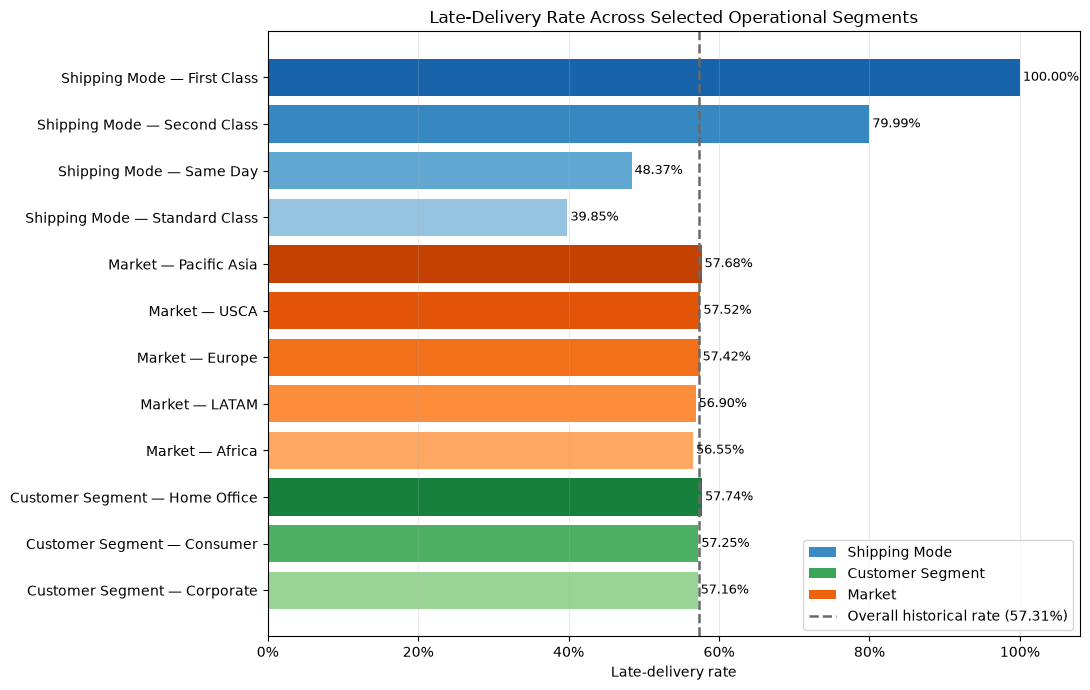

In [12]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch


# Prepare the plotting data.
segment_plot_data = (
    segment_delivery_summary
    .sort_values(
        ["Segment", "Late-delivery rate"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
    .copy()
)

segment_plot_data["Label"] = (
    segment_plot_data["Segment"]
    + " — "
    + segment_plot_data["Category"].astype(str)
)


# Define one colour family for each segment.
segment_palettes = {
    "Shipping Mode": cm.Blues,
    "Customer Segment": cm.Greens,
    "Market": cm.Oranges,
}


# Assign different shades within each segment.
bar_colors = []

for segment_name, group in segment_plot_data.groupby(
    "Segment",
    sort=False,
):
    palette = segment_palettes[segment_name]

    shade_positions = [
        0.40 + (
            0.40 * i / max(len(group) - 1, 1)
        )
        for i in range(len(group))
    ]

    bar_colors.extend(
        [palette(position) for position in shade_positions]
    )


# Create the chart.
segment_fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    segment_plot_data["Label"],
    segment_plot_data["Late-delivery rate"],
    color=bar_colors,
)


# Add the overall historical reference line.
ax.axvline(
    late_delivery_rate,
    linestyle="--",
    linewidth=1.8,
    color="dimgray",
    label=(
        "Overall historical rate "
        f"({late_delivery_rate:.2%})"
    ),
)


# Add the rate value beside each bar.
for bar, rate in zip(
    bars,
    segment_plot_data["Late-delivery rate"],
):
    ax.text(
        rate + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2%}",
        va="center",
        ha="left",
        fontsize=9,
    )


# Format the chart.
ax.set_title(
    "Late-Delivery Rate Across Selected Operational Segments"
)

ax.set_xlabel(
    "Late-delivery rate"
)

ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.grid(
    axis="x",
    alpha=0.25,
)


# Add segment-level colour legend.
segment_legend = [
    Patch(
        facecolor=cm.Blues(0.65),
        label="Shipping Mode",
    ),
    Patch(
        facecolor=cm.Greens(0.65),
        label="Customer Segment",
    ),
    Patch(
        facecolor=cm.Oranges(0.65),
        label="Market",
    ),
]

segment_legend.append(
    plt.Line2D(
        [0],
        [0],
        color="dimgray",
        linestyle="--",
        linewidth=1.8,
        label=(
            "Overall historical rate "
            f"({late_delivery_rate:.2%})"
        ),
    )
)

ax.legend(
    handles=segment_legend,
    loc="lower right",
)


# Leave space for rate labels.
ax.set_xlim(
    0,
    max(
        segment_plot_data[
            "Late-delivery rate"
        ].max() + 0.08,
        1.02,
    ),
)

segment_fig.tight_layout()

plt.show()

### 2.4 AQ2 - Compare selected order profiles  
  
**Project workflow role:**  
The analysis compares three order attributes that are available at order creation and have clear business meaning:  
  
- `Order Item Count`: [order structure complexity] the number of order-line records in an order. 
- `Order Quantity`: [order volume] the total number of product units in an order. 
- `Order Value`: [order monetary value] the total monetary value of an order.
  
For each attribute, the `mean` and `median` are compared between late and on-time orders.  

In [13]:
# Compare selected numerical order profiles by delivery outcome.
order_profile_summary = duckdb_connection.sql(
    """
    SELECT
        CASE
            WHEN late_delivery_risk = 1
                THEN 'Late'
            ELSE 'On time'
        END AS "Delivery outcome",

        COUNT(*) AS "Eligible orders",

        AVG(order_item_count)
            AS "Mean item count",

        MEDIAN(order_item_count)
            AS "Median item count",

        AVG(order_quantity)
            AS "Mean order quantity",

        MEDIAN(order_quantity)
            AS "Median order quantity",

        AVG(order_value)
            AS "Mean order value",

        MEDIAN(order_value)
            AS "Median order value"

    FROM orders_analysis

    GROUP BY late_delivery_risk

    ORDER BY late_delivery_risk DESC
    """
).df()


display(
    order_profile_summary.style.format({
        "Eligible orders": "{:,.0f}",
        "Mean item count": "{:.2f}",
        "Median item count": "{:.2f}",
        "Mean order quantity": "{:.2f}",
        "Median order quantity": "{:.2f}",
        "Mean order value": "{:,.2f}",
        "Median order value": "{:,.2f}",
    })
)

,Delivery outcome,Eligible orders,Mean item count,Median item count,Mean order quantity,Median order quantity,Mean order value,Median order value
0,Late,"36,048",2.75,3.00,5.84,5.00,501.62,455.95
1,On time,"26,849",2.75,3.00,5.85,5.00,505.13,457.56


**Key observations**

- `Order Item Count` is very similar between late and on-time orders, with the same median in both groups.
- `Order Quantity` also shows little descriptive separation between the two delivery outcomes.
- `Order Value` differs only slightly between late and on-time orders in both mean and median values.
- Overall, these selected order-size measures show much weaker descriptive differences than the categorical differences observed for `Shipping Mode`.

These results suggest that the selected order-size attributes alone do not clearly distinguish late from on-time orders. The relationships are descriptive and do not imply causation.

## 3. Compare a time-aware risk ranking with non-informative baseline  — AQ3  
    
Using the order-creation attributes, this section
- Define a fair prediction setup   
    - feature selection (only those available at order creation)  
    - time-aware splitting (past training - furthre test)  
- Create   
    - a Machine Learning (ML) model for the risk ranking prediction    
    - a non-informative baseline  
- Compare the created model with the baseline  
- Save model output 
  
This section answers the AQ3:  
**Using only information available at order creation, can a time-aware model rank future orders by late-delivery risk more effectively than a non-informative baseline?**    

### 3.1 Prepare leakage-safe features and create the temporal split

This section converts the field-use rules into a fixed, model-ready design for AQ3. Before either model is fitted, it:

1. selects a compact set of features available at order creation;
2. separates features from identifiers, the target, post-order information, and later Analyze-derived fields; and
3. divides the validated complete-week history chronologically into training and held-out test periods.

**Final predictor set**

| Feature type | Features                                            |
| ------------ | ----------------------------------------------------- |
| Categorical  | `Shipping Mode`, `Type`, `Customer Segment`, `Market` |
| Numerical    | `Order Item Count`, `Order Quantity`, `Order Value`   |

These seven features are retained because they have clear business meaning and are treated as available when an order is created.

**Fields not used as features**

| Field or field group                                            | Use or exclusion reason                                                                                                        |
| --------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| `Order Id`                                                      | Retained only for result traceability and later review-queue outputs. Identifiers are not generalisable order characteristics. |
| `order date (DateOrders)`                                       | Used to define the complete-week modelling window and chronological split.                 |
| `Late_delivery_risk`                                            | Used only as the prediction target and evaluation outcome.                                                                     |
| `shipping date (DateOrders)`, `Days for shipping (real)`        | Excluded because they become available after order creation and would introduce data leakage.                                  |
| `Days for shipment (scheduled)`                                 | Omitted to avoid conceptual overlap with the retained `Shipping Mode` field.                                                   |
| `Product Count`                                                 | Omitted to avoid overlap with the retained `Order Item Count` field.                                                           |
| `Order Region`                                                  | Omitted so that the model uses one simpler geographic representation, `Market`.                                                |
| `risk_score`, `risk_rank`, `high_risk_flag`, and capacity flags | Created later in the Analyze phase and not be used as features.                                              |

The three overlapping fields are omitted to keep the model compact and interpretable; they are not excluded because of data leakage.

**Frozen leakage boundary**

The following rules apply throughout the risk-ranking analysis:

1. Only information treated as available at order creation may be used as a feature.
2. The feature set is fixed before held-out test performance is examined.
3. Feature preprocessing is fitted using the training period only and then applied unchanged to the test period.
4. Post-order outcomes and Analyze-derived fields are never introduced into the predictive inputs.
5. The held-out test-period outcomes are used only for the final model evaluation in Section 3.3.

> **Portfolio assumption:** The selected operational and order-composition fields are treated as available at order creation. The source data does not provide a separate event timestamp for every field, so this availability assumption should be considered when interpreting the model results.

**Temporal split**

Only orders covered by the validated complete Monday-to-Sunday weeks are retained for modelling. The weeks are sorted chronologically and split without random shuffling:

* the earliest `80%` of complete weeks form the training period;
* the most recent `20%` form the held-out test period; and
* all orders from the same week remain in the same partition.

For the current dataset, this produces:

* `128` complete training weeks; and
* `32` complete test weeks.

Using earlier weeks for training and later weeks for testing simulates the intended task of applying historical patterns to future orders and prevents future-period information from entering model fitting.

**Data preprocessing**

**DP1. Define the model fields and complete-week window**

In [14]:
from math import ceil


# Define model fields according to the frozen leakage boundary.
categorical_features = [
    "Shipping Mode",
    "Type",
    "Customer Segment",
    "Market",
]

numerical_features = [
    "Order Item Count",
    "Order Quantity",
    "Order Value",
]

feature_columns = categorical_features + numerical_features

id_column = "Order Id"
date_column = "order date (DateOrders)"
target_column = "Late_delivery_risk"

trace_columns = [
    id_column,
    date_column,
]


# Derive the split boundary from the validated complete-week dataset.
TEST_WEEK_RATIO = 0.20

complete_weeks = (
    weekly_df["Week Start"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

test_week_count = ceil(
    len(complete_weeks) * TEST_WEEK_RATIO
)

train_weeks = complete_weeks.iloc[:-test_week_count]
test_weeks = complete_weeks.iloc[-test_week_count:]

test_start_week = test_weeks.iloc[0]

complete_period_start = complete_weeks.iloc[0]
complete_period_end = (
    complete_weeks.iloc[-1]
    + pd.Timedelta(days=7)
)


# Keep only orders covered by validated complete weeks.
model_columns = (
    trace_columns
    + feature_columns
    + [target_column]
)

complete_period_mask = (
    order_df[date_column].ge(complete_period_start)
    & order_df[date_column].lt(complete_period_end)
)

model_df = (
    order_df.loc[
        complete_period_mask,
        model_columns,
    ]
    .sort_values([date_column, id_column])
    .reset_index(drop=True)
)

In [15]:
# Summarise the modelling window and retained data.
preparation_summary = pd.DataFrame([{
    "Complete weeks": len(complete_weeks),
    "Period start": complete_period_start.date(),
    "Period end": (
        complete_period_end
        - pd.Timedelta(days=1)
    ).date(),
    "Orders retained": len(model_df),
    "Features": len(feature_columns),
}])

display(
    preparation_summary.style.format({
        "Orders retained": "{:,}",
    })
)

,Complete weeks,Period start,Period end,Orders retained,Features
0,160,2015-01-05,2018-01-28,"62,474",7


**DP2. Create and validate the temporal split**

In [16]:
# Assign earlier orders to training and later orders to testing.
train_mask = model_df[date_column] < test_start_week
test_mask = ~train_mask


# Create the predictor and target datasets.
X_train = (
    model_df.loc[train_mask, feature_columns]
    .reset_index(drop=True)
)

X_test = (
    model_df.loc[test_mask, feature_columns]
    .reset_index(drop=True)
)

y_train = (
    model_df.loc[train_mask, target_column]
    .reset_index(drop=True)
)

y_test = (
    model_df.loc[test_mask, target_column]
    .reset_index(drop=True)
)

In [17]:
# Preserve test-order identifiers for later evaluation and review outputs.
test_order_info = (
    model_df.loc[test_mask, trace_columns]
    .reset_index(drop=True)
)

In [18]:
# Verify row alignment and chronological separation.
assert len(train_weeks) + len(test_weeks) == len(complete_weeks)
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test) == len(test_order_info)

assert (
    model_df.loc[train_mask, date_column].max()
    < model_df.loc[test_mask, date_column].min()
)

In [19]:
# Preview the first five rows of each training and test dataset.
print("X_train")
display(X_train.head())

print("y_train")
display(y_train.head())

print("X_test")
display(X_test.head())

print("y_test")
display(y_test.head())

X_train


,Shipping Mode,Type,Customer Segment,Market,Order Item Count,Order Quantity,Order Value
0,Same Day,TRANSFER,Corporate,LATAM,2,3,184.970001
1,Standard Class,PAYMENT,Consumer,LATAM,4,16,666.290005
2,Standard Class,DEBIT,Home Office,LATAM,1,2,179.979996
3,Standard Class,TRANSFER,Consumer,LATAM,1,1,118.290001
4,Standard Class,PAYMENT,Consumer,LATAM,4,11,892.360016


y_train


0    0
1    0
2    1
3    1
4    0
Name: Late_delivery_risk, dtype: int64

X_test


,Shipping Mode,Type,Customer Segment,Market,Order Item Count,Order Quantity,Order Value
0,Standard Class,TRANSFER,Consumer,Europe,3,5,310.989998
1,Standard Class,CASH,Consumer,Europe,1,1,191.990005
2,Standard Class,DEBIT,Corporate,Europe,2,10,395.870010
3,Standard Class,DEBIT,Consumer,Europe,2,2,438.270012
4,Standard Class,DEBIT,Consumer,Europe,5,10,985.840019


y_test


0    0
1    0
2    0
3    1
4    1
Name: Late_delivery_risk, dtype: int64

In [20]:
# Summarise the resulting training and test periods.
split_summary = pd.DataFrame([
    {
        "Dataset": "Training",
        "Complete weeks": len(train_weeks),
        "Period start": train_weeks.iloc[0].date(),
        "Period end": (
            train_weeks.iloc[-1]
            + pd.Timedelta(days=6)
        ).date(),
        "Orders": len(X_train),
        "Late-delivery rate": y_train.mean(),
    },
    {
        "Dataset": "Test",
        "Complete weeks": len(test_weeks),
        "Period start": test_weeks.iloc[0].date(),
        "Period end": (
            test_weeks.iloc[-1]
            + pd.Timedelta(days=6)
        ).date(),
        "Orders": len(X_test),
        "Late-delivery rate": y_test.mean(),
    },
])

display(
    split_summary.style.format({
        "Orders": "{:,}",
        "Late-delivery rate": "{:.2%}",
    })
)

,Dataset,Complete weeks,Period start,Period end,Orders,Late-delivery rate
0,Training,128,2015-01-05,2017-06-18,"48,949",57.25%
1,Test,32,2017-06-19,2018-01-28,"13,525",57.59%


### 3.2 Build the models and generate test-period risk scores  


This subsection completes the model-building stage by  
- selecting the modelling approach,  
- fitting all learnable steps on the training period, and    
- generating risk scores for the unseen test period.  
  
The workflow is:  
  
1. Select an appropriate baseline and predictive model.  
2. Build a leakage-safe preprocessing and modelling pipeline.  
3. Fit both models using the training set only.  
4. Generate and validate test-period probabilities.  
  
The resulting scores are evaluated in Section 3.3.

#### 3.2.1 Select the Baseline and modelling approach 

**Workflow step**

This step selects the models used to establish a **non-informative baseline** and produce **order-level late-delivery risk scores**.

**Method and rationale**

Two deliberately simple models are selected:

(1) **Dummy classifier:**  
    - With `strategy="prior"`, the model learns only the class distribution in `y_train`.  
    - It ignores relationships between the order features and the target.  
    - Every order receives the uniform late-delivery probability, equal to the training-set late-delivery rate.  
    - For example, if 58% of training orders are late, every test order receives a probability of 0.58.  
    - It therefore provides a non-informative baseline for assessing whether logistic regression adds useful order-level risk differentiation.  
  
(2) **Logistic regression:**  
    - The model calculates a **weighted combination** of the input features.  
    - A **sigmoid function** converts this value into a probability between 0 and 1.  
    - The probability represents the **estimated likelihood** that `Late_delivery_risk = 1`.  
    - The **feature weights** are learned from `X_train` and `y_train` by minimising prediction error.  
    - Different feature values ultimately produce different probabilities for individual orders.  
  
These probabilities can be used as continuous risk scores to rank orders from higher to lower late-delivery risk.  
  
**Implementation**  
    - Define a `DummyClassifier` using `strategy="prior"`.  
    - Define a logistic regression model within a preprocessing pipeline.  
    - Fit both models on the same training period to support a fair comparison.

#### 3.2.2 Build and fit the dummy baseline

**Build and fit a Dummy classifier**

In [21]:
from sklearn.dummy import DummyClassifier


# Define and fit the non-informative baseline.
baseline_model = DummyClassifier(strategy="prior")
baseline_model.fit(X_train, y_train)

print("Dummy classifier fitted successfully.")

Dummy classifier fitted successfully.


#### 3.2.3 Build and fit logistic regression model

**Define One-hot encoding**

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Define preprocessing for categorical and numerical predictors.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features,
        ),
    ]
)

print("Preprocessor defined successfully.")

Preprocessor defined successfully.


**Build the Logistic Regression pipeline**

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


# Connect preprocessing and logistic regression in one pipeline.
risk_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

print("Logistic regression pipeline created successfully.")

Logistic regression pipeline created successfully.


**Fit and confirm the model**

In [24]:
# Fit all preprocessing steps and model parameters
# using the training data only.
risk_model.fit(X_train, y_train)


# Confirm that the model has been fitted.
model_classes = (
    risk_model
    .named_steps["classifier"]
    .classes_
)

print("Logistic regression model fitted successfully.")
print(f"Training orders: {len(X_train):,}")
print(f"Original features: {X_train.shape[1]}")
print(f"Model classes: {model_classes.tolist()}")

Logistic regression model fitted successfully.
Training orders: 48,949
Original features: 7
Model classes: [0, 1]


#### 3.2.4 Generate and check test-period risk scores

**Generate test-period probabilities**

In [25]:
# Locate the positive-class probability column for each fitted model.
baseline_positive_index = list(
    baseline_model.classes_
).index(1)

model_positive_index = list(
    risk_model.named_steps["classifier"].classes_
).index(1)


# Generate probabilities for Late_delivery_risk = 1.
baseline_test_scores = pd.Series(
    baseline_model.predict_proba(X_test)[:, baseline_positive_index],
    index=X_test.index,
    name="baseline_risk_score",
)

model_test_scores = pd.Series(
    risk_model.predict_proba(X_test)[:, model_positive_index],
    index=X_test.index,
    name="model_risk_score",
)

# Create a simple preview of the first-five generated probabilities.
score_preview = pd.DataFrame(
    {
        "baseline_risk_score": baseline_test_scores,
        "model_risk_score": model_test_scores,
    }
)

display(score_preview.head())

,baseline_risk_score,model_risk_score
0,0.572535,0.405578
1,0.572535,0.399568
2,0.572535,0.395250
3,0.572535,0.398725
4,0.572535,0.394219


**Create the scored test dateset**

In [26]:
# retained during the temporal split.
test_scored_df = test_order_info.copy()


# Add the generated risk scores.
test_scored_df[target_column] = y_test
test_scored_df["baseline_risk_score"] = baseline_test_scores
test_scored_df["model_risk_score"] = model_test_scores


# Display the resulting dataset.
print(f"Rows: {test_scored_df.shape[0]:,}")
print(f"Columns: {test_scored_df.shape[1]}")

display(test_scored_df.head())

Rows: 13,525
Columns: 5


,Order Id,order date (DateOrders),Late_delivery_risk,baseline_risk_score,model_risk_score
0,61656,2017-06-19 00:29:00,0,0.572535,0.405578
1,61657,2017-06-19 00:50:00,0,0.572535,0.399568
2,61658,2017-06-19 01:11:00,0,0.572535,0.395250
3,61659,2017-06-19 01:32:00,1,0.572535,0.398725
4,61660,2017-06-19 01:53:00,1,0.572535,0.394219


### 3.3 Evaluate model performance on the held-out test period

#### 3.3.1 Introduce the evaluation metrics

**Workflow step**  
  
This step evaluates whether the fitted logistic regression model provides better order-level risk differentiation than the dummy baseline on the held-out test period. No model is retrained or modified in this section.

**Method and rationale**

Two threshold-independent ranking metrics are used:

- **Average Precision (AP)** evaluates how effectively the model concentrates actual late orders near the top of the risk ranking. A higher AP indicates better risk differentiation, while the dummy baseline AP is expected to equal the test-period late-delivery rate (Appendix).  
 
$$
\mathrm{AP}
=
\sum_{n}
\left(R_n-R_{n-1}\right)P_n
$$

where:

* (Pn) is the Precision at the (n)-th risk-score threshold.
* (Rn) is the Recall at the (n)-th risk-score threshold.
* (Rn-R{n-1}) is the increase in Recall produced at that threshold.

- **ROC-AUC** evaluates how effectively the model ranks late orders above non-late orders across all possible score thresholds. A dummy baseline is expected to produce a ROC-AUC of 0.50.  

$$  
\mathrm{ROC-AUC}
=
\int_{0}^{1}
\mathrm{TPR}(\mathrm{FPR}),d(\mathrm{FPR})
$$

where:  
  
- TPR is the True Positive Rate at a given risk-score threshold.  
- FPR is the False Positive Rate at that threshold.  
- FPR is a small change in the False Positive Rate.  

The two rates are calculated as:
  
$$
\frac{TP}{TP+FN}
$$  
  
$$
\frac{FP}{FP+TN}
$$  
  
where:  
  
- TP is the number of actual late orders correctly identified as high risk.  
- FN is the number of actual late orders not identified as high risk.  
- FP is the number of non-late orders incorrectly identified as high risk.  
- TN is the number of non-late orders correctly identified as non-high-risk.    

The dummy model provides a non-informative reference:

* Its Average Precision should equal the late-delivery rate in the test period.
* Its ROC-AUC should equal 0.50.
* Logistic regression should exceed these reference values if it provides better statistical risk differentiation.

The project objective is to rank orders under limited review capacity. Therefore, this section evaluates continuous risk scores rather than applying a fixed classification threshold. Accuracy, a confusion matrix, and threshold-specific classification measures are not used here.

**Implementation**

* Use the actual outcomes and risk scores stored in `test_scored_df`.
* Calculate Average Precision and ROC-AUC for both models.
* Compare logistic regression with the dummy baseline.
* Plot the precision-recall and ROC curves.
* Summarise whether logistic regression outperforms the baseline.

This section evaluates statistical ranking performance. Operational usefulness under the 5%, 10%, and 20% review-capacity scenarios is evaluated in Section 3.4.


#### 3.3.2 Calculate and compare AP and ROC-AUC

**Calculate the evaluation metrics**

In [27]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


# Retrieve the actual outcomes and generated risk scores.
actual_outcomes = test_scored_df[target_column]

baseline_scores = test_scored_df[
    "baseline_risk_score"
]

model_scores = test_scored_df[
    "model_risk_score"
]



# Calculate Average Precision.
baseline_ap = average_precision_score(
    actual_outcomes,
    baseline_scores,
)

model_ap = average_precision_score(
    actual_outcomes,
    model_scores,
)


# Calculate ROC-AUC.
baseline_roc_auc = roc_auc_score(
    actual_outcomes,
    baseline_scores,
)

model_roc_auc = roc_auc_score(
    actual_outcomes,
    model_scores,
)


# Create the model-comparison table.
evaluation_results = pd.DataFrame(
    {
        "dummy_baseline": [
            baseline_ap,
            baseline_roc_auc,
        ],
        "logistic_regression": [
            model_ap,
            model_roc_auc,
        ],
    },
    index=[
        "Average Precision (AP)",
        "ROC-AUC",
    ],
)

evaluation_results["absolute_improvement"] = (
    evaluation_results["logistic_regression"]
    - evaluation_results["dummy_baseline"]
)

evaluation_results.index.name = "metric"


# Display the evaluation results.
display(evaluation_results.round(4))

,dummy_baseline,logistic_regression,absolute_improvement
metric,,,
Average Precision (AP),0.5759,0.8382,0.2623
ROC-AUC,0.5000,0.7473,0.2473


#### 3.3.3 Plot and interpret the Precision-Recall curve

Section 3.3.2 showed that Logistic Regression outperformed the Dummy baseline on the held-out test period:

* Average Precision increased from `0.5759` to `0.8382`.
* ROC-AUC increased from `0.5000` to `0.7473`.

These summary metrics establish that Logistic Regression provides stronger overall risk ranking. However, Average Precision compresses the model's precision–recall performance across different risk-score thresholds into a single value. It does not show how precision changes as more actual late orders are captured.

The precision–recall curve expands this result by evaluating every possible Logistic Regression risk-score threshold:

* orders at or above a threshold are treated as the higher-risk group;
* **precision** measures the proportion of selected orders that were actually late; and
* **recall** measures the proportion of all actual late orders captured by the selected group.

A higher threshold usually selects fewer orders, which may produce higher precision but lower recall. As the threshold is lowered, more orders are selected, recall generally increases, and precision may decrease.

The held-out test-period late-order prevalence, `0.5759`, is added as the horizontal no-skill baseline. It represents the expected precision when orders cannot be meaningfully prioritised and also corresponds to the Dummy baseline Average Precision.

The curve can be interpreted by examining:

1. whether Logistic Regression remains above the prevalence baseline across a useful recall range;
2. how precision changes as recall increases; and
3. whether the model provides sufficient ranking value to proceed to the review-capacity simulation.

This section does not select an operational risk-score threshold. Section 4 will reuse the same frozen held-out test-period risk scores and determine the implied cutoffs under the `5%`, `10%`, and `20%` review-capacity scenarios.

The analysis sequence is therefore:

**Summary metric comparison → Precision–recall trade-off → Model evaluation conclusion → Review-capacity simulation**


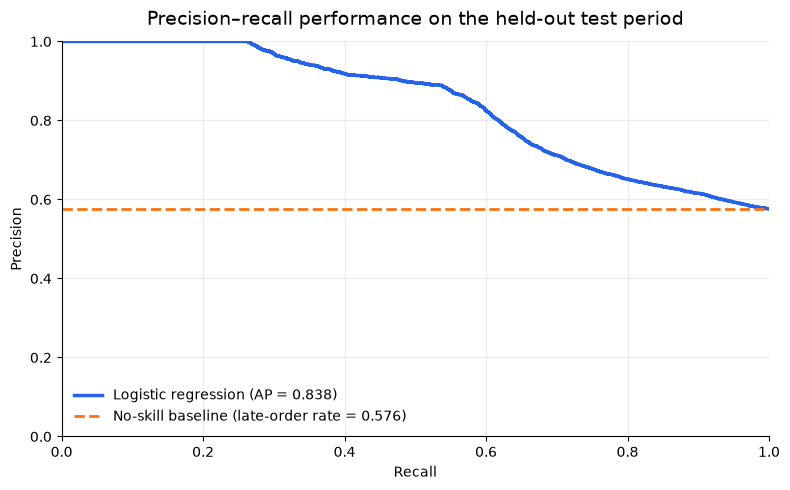

In [28]:
# Calculate the precision-recall curve for Logistic Regression.
model_precision, model_recall, _ = precision_recall_curve(
    actual_outcomes,
    model_scores,
)

# Calculate the no-skill baseline using the test-period late-order prevalence.
late_order_prevalence = actual_outcomes.mean()

# Prepare the precision-recall curve data for Power BI.
precision_recall_curve_data = pd.DataFrame(
    {
        "recall": model_recall,
        "precision": model_precision,
        "baseline": late_order_prevalence,
    }
)

# Plot the precision-recall curve.
precision_recall_fig, ax = plt.subplots(figsize=(8, 5))

ax.step(
    model_recall,
    model_precision,
    where="post",
    color="#2563EB",
    linewidth=2.5,
    label=f"Logistic regression (AP = {model_ap:.3f})",
)

ax.axhline(
    y=late_order_prevalence,
    color="#F97316",
    linestyle="--",
    linewidth=2,
    label=(
        "No-skill baseline "
        f"(late-order rate = {late_order_prevalence:.3f})"
    ),
)


# Format the chart.
ax.set_title(
    "Precision–recall performance on the held-out test period",
    fontsize=14,
    pad=12,
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower left",
)

precision_recall_fig.tight_layout()
plt.show()

**Observations**

* The Logistic Regression precision–recall curve remains above the non-informative baseline across most of the recall range, consistent with its higher Average Precision (`0.8382` versus `0.5759`).
* Precision is generally higher when the model focuses on the highest-risk orders and decreases as recall expands, illustrating the trade-off between review accuracy and late-order coverage.
* The curve supports using Logistic Regression for risk prioritisation. However, it does not determine an operational cutoff; the `5%`, `10%`, and `20%` review-capacity scenarios will be evaluated in Section 4.


#### 3.3.4 Summarise the model evaluation findings

Section 3.3 evaluated whether Logistic Regression provides more useful late-delivery risk ranking than the Dummy baseline on the held-out test period.

The evaluation evidence forms the following chain:

1. The Dummy baseline produced an Average Precision of `0.5759`, equal to the test-period late-order prevalence, and a ROC-AUC of `0.5000`. These results represent no meaningful risk-ranking ability.
2. Logistic Regression increased Average Precision to `0.8382`, showing that its higher-risk selections contain late orders more consistently across the precision–recall trade-off.
3. Its ROC-AUC of `0.7473` provides additional evidence that the model generally assigns higher risk scores to late orders than to non-late orders.
4. The precision–recall curve expands the Average Precision result by showing how precision changes as more actual late orders are captured.

Together, these results show that Logistic Regression provides substantially stronger risk-ranking value than the Dummy baseline on the held-out test period. The Logistic Regression scores will therefore be carried forward into Section 4 for the review-capacity simulation.

This conclusion does not establish that Logistic Regression is the best possible model or determine an operational risk-score cutoff. Because the project focuses on prioritisation under limited review capacity rather than fixed-threshold classification, Section 4 will rank the same frozen test-period scores and evaluate the `5%`, `10%`, and `20%` capacity scenarios.

**Evaluation logic:**
**No-skill comparison → Held-out ranking evidence → Use Logistic Regression scores → Review-capacity simulation**


## 4. Simulate limited review capacity - AQ4

### AQ4: When review capacity is limited to 5%, 10%, or 20% of eligible orders, which orders should be reviewed first, and what late-order recall, precision, and lift would the queue achieve in the held-out test period?

This section follows five steps:

1. Use the frozen risk scores produced for the held-out test-period orders in AQ3.

2. Rank the orders from highest to lowest predicted late-delivery risk, using `Order Id` only as a deterministic tie-breaker.

3. For each 5%, 10%, and 20% capacity scenario, calculate the review limit as:

$$[
\text{Review limit}
=
\left\lceil
\text{Capacity ratio}
\times
\text{Eligible test orders}
\right\rceil
]$$

Select the corresponding number of top-ranked orders as the simulated review group.

4. Compare the capacity scenarios using the following predefined metrics:

**M08 — Late-order recall (capture rate)**

The proportion of all actual late orders in the eligible test-period population that are included in the selected review group.

$$[
\text{Late-order recall}
=
\frac{
\text{Late orders selected for review}
}{
\text{All actual late orders}
}
]$$

**M09 — Review precision**

The proportion of all orders selected for review that were actually late.

$$[
\text{Review precision}
=
\frac{
\text{Late orders selected for review}
}{
\text{All orders selected for review}
}
]$$

**M10 — Lift over baseline**

The concentration of actual late orders in the selected review group relative to the overall late-order rate in the eligible test-period population.

$$[
\text{Lift over baseline}
=
\frac{
\text{Review precision}
}{
\text{Overall late-order rate}
}
]$$

5. Use the scenario comparison to explain the trade-off between review capacity and late-order coverage, and create an illustrative historical review queue from the ranked held-out test-period orders.

This section does not fit or tune another model. It uses the frozen AQ3 risk scores to evaluate how the existing risk ranking would perform under different operational capacity constraints.

The capacity-based approach does not apply an arbitrary classification threshold such as `0.5`. Instead, each cutoff is determined by the number of orders that the simulated review process can accommodate.

**Analysis logic:**
**Frozen held-out test-period risk scores → Risk ranking → 5%, 10%, and 20% capacity-based selection → Recall, precision, and lift comparison → Illustrative historical review queue**


### 4.1 Rank held-out test-period orders by predicted risk

This subsection converts the frozen Logistic Regression risk scores into a fixed order-level risk ranking.

The analysis follows these steps:

1. Match each eligible held-out order with its Logistic Regression `risk_score`.
2. Sort the orders by `risk_score` from highest to lowest.
3. Use `Order Id` as a deterministic tie-breaker when two orders have the same risk score.
4. Assign a sequential `risk_rank`, where rank `1` represents the order with the highest predicted late-delivery risk.
  
**Analysis logic:**
**Frozen risk scores → Descending risk order → Deterministic tie-breaking → Fixed risk ranking**


**Match test orders with risk scores**

In [29]:
# create a new df retaining Order Id and risk score
ranking_input = (
    test_scored_df[
        [
            id_column,
            "model_risk_score",
        ]
    ]
    .rename(
        columns={
            "model_risk_score": "risk_score",
        }
    )
    .copy()
)

display(ranking_input)

,Order Id,risk_score
0,61656,0.405578
1,61657,0.399568
2,61658,0.395250
3,61659,0.398725
4,61660,0.394219
...,...,...
13520,76995,0.804392
13521,76996,0.801685
13522,76997,0.999303
13523,76998,0.404490


**Sort by risk score**

In [30]:
# Create a risk-score-descending df
ranked_test_orders = (
    ranking_input
    .sort_values(
        by=[
            "risk_score",
            id_column, # for the orders with the same risk scores
        ],
        ascending=[
            False, 
            True,  # rank them inscendingly
        ],
    )
    .reset_index(drop=True)
)

display(ranked_test_orders)

,Order Id,risk_score
0,73312,0.999317
1,73313,0.999317
2,73457,0.999317
3,73226,0.999317
4,73245,0.999317
...,...,...
13520,68875,0.370190
13521,68806,0.370098
13522,68809,0.368986
13523,68858,0.367955


**Assign a sequential risk rank attribute**

In [31]:
ranked_test_orders.insert(
    0,
    "risk_rank",
    range(1, len(ranked_test_orders) + 1),
)

display(ranked_test_orders)

,risk_rank,Order Id,risk_score
0,1,73312,0.999317
1,2,73313,0.999317
2,3,73457,0.999317
3,4,73226,0.999317
4,5,73245,0.999317
...,...,...,...
13520,13521,68875,0.370190
13521,13522,68806,0.370098
13522,13523,68809,0.368986
13523,13524,68858,0.367955


### 4.2 Simulate the review-capacity scenarios

This subsection applies the `5%`, `10%`, and `20%` review-capacity scenarios to the fixed risk ranking created in Section 4.1.  
  
The simulation follows these steps:  
  
1. Define the three review-capacity ratios: `5%`, `10%`, and `20%`.  
  
2. For each scenario, calculate the number of orders that can be reviewed.    
  
3. Select the top-ranked orders whose `risk_rank` falls within the calculated review limit.  
  
4. Create a separate review group for each capacity scenario.  
    
**Analysis logic:**
**Fixed Capacity shares → Review limits → Top-ranked orders in each scenario → three review groups**

**Define the capacity ratios**

In [32]:
capacity_scenarios = pd.DataFrame(
    {
        "capacity_scenario": [
            "5%",
            "10%",
            "20%",
        ],
        "capacity_ratio": [
            0.05,
            0.10,
            0.20,
        ],
    }
)


# Display the defined scenarios.
display(
    capacity_scenarios.style.format(
        {
            "capacity_ratio": "{:.2%}",
        }
    )
)

,capacity_scenario,capacity_ratio
0,5%,5.00%
1,10%,10.00%
2,20%,20.00%


**Calculate the review limits**

In [33]:
from math import ceil


eligible_order_count = len(ranked_test_orders)

assert eligible_order_count > 0


capacity_scenarios["review_limit"] = [
    ceil(capacity_ratio * eligible_order_count)
    for capacity_ratio in capacity_scenarios["capacity_ratio"]
]


# Display the calculated review limits.
print(f"Eligible held-out orders: {eligible_order_count:,}")

display(
    capacity_scenarios.style.format(
        {
            "capacity_ratio": "{:.2%}",
            "review_limit": "{:,d}",
        }
    )
)

Eligible held-out orders: 13,525


,capacity_scenario,capacity_ratio,review_limit
0,5%,5.00%,677
1,10%,10.00%,"1,353"
2,20%,20.00%,"2,705"


**Identify top-ranked orders**

In [34]:
scenario_rankings = {}


for scenario, review_limit in capacity_scenarios[
    [
        "capacity_scenario",
        "review_limit",
    ]
].itertuples(index=False, name=None):

    scenario_table = ranked_test_orders.copy()

    scenario_table["selected_for_review"] = (
        scenario_table["risk_rank"] <= review_limit
    )

    scenario_rankings[scenario] = scenario_table

display(scenario_rankings)

{'5%':        risk_rank  Order Id  risk_score  selected_for_review
 0              1     73312    0.999317                 True
 1              2     73313    0.999317                 True
 2              3     73457    0.999317                 True
 3              4     73226    0.999317                 True
 4              5     73245    0.999317                 True
 ...          ...       ...         ...                  ...
 13520      13521     68875    0.370190                False
 13521      13522     68806    0.370098                False
 13522      13523     68809    0.368986                False
 13523      13524     68858    0.367955                False
 13524      13525     68703    0.366103                False
 
 [13525 rows x 4 columns],
 '10%':        risk_rank  Order Id  risk_score  selected_for_review
 0              1     73312    0.999317                 True
 1              2     73313    0.999317                 True
 2              3     73457    0.999317    

**Create the review groups**

In [35]:
review_groups = {
    scenario: scenario_table.loc[
        scenario_table["selected_for_review"]
    ]
    .drop(columns="selected_for_review")
    .reset_index(drop=True)
    for scenario, scenario_table in scenario_rankings.items()
}


# Assign clear names to the three simulated review groups.
review_group_5pct = review_groups["5%"]
review_group_10pct = review_groups["10%"]
review_group_20pct = review_groups["20%"]


# Display the number of selected orders in each group.
for scenario, review_group in review_groups.items():
    print(
        f"{scenario} capacity: "
        f"{len(review_group):,} orders selected"
    )

display(review_group_5pct)
display(review_group_10pct)
display(review_group_20pct)

5% capacity: 677 orders selected
10% capacity: 1,353 orders selected
20% capacity: 2,705 orders selected


,risk_rank,Order Id,risk_score
0,1,73312,0.999317
1,2,73313,0.999317
2,3,73457,0.999317
3,4,73226,0.999317
4,5,73245,0.999317
...,...,...,...
672,673,72595,0.999291
673,674,69379,0.999291
674,675,73027,0.999291
675,676,69218,0.999291


,risk_rank,Order Id,risk_score
0,1,73312,0.999317
1,2,73313,0.999317
2,3,73457,0.999317
3,4,73226,0.999317
4,5,73245,0.999317
...,...,...,...
1348,1349,67620,0.999277
1349,1350,72215,0.999277
1350,1351,64669,0.999277
1351,1352,70342,0.999277


,risk_rank,Order Id,risk_score
0,1,73312,0.999317
1,2,73313,0.999317
2,3,73457,0.999317
3,4,73226,0.999317
4,5,73245,0.999317
...,...,...,...
2700,2701,75035,0.803284
2701,2702,71040,0.803283
2702,2703,62893,0.803280
2703,2704,71674,0.803275


### 4.3 Compare the ranking performance with late-order capture, precision, and lift

This subsection evaluates the historical performance of the `5%`, `10%`, and `20%` review groups created in Section 4.2.  
  
The evaluation follows these steps:  
  
1. Calculate the overall late-order rate among all eligible held-out orders. This provides the baseline for comparison.
2. Match the actual delivery outcome to each order in the three simulated review groups.
3. For each scenario, count:

   * the number of orders selected for review; and
   * the number of selected orders that were actually late.
4. Calculate the following evaluation metrics:

   * **Late-order capture rate:** the proportion of all actual late orders captured by the review group;
   * **Review precision:** the proportion of reviewed orders that were actually late; and
   * **Lift over baseline:** the concentration of late orders in the review group relative to the overall held-out late-order rate.
5. Combine the results into one comparison table and examine the trade-off between review capacity, late-order coverage, and review efficiency.  
6. Perform a supplementary capacity sensitivity check by:    
   * expanding the review group one ranked order at a time;  
   * calculating cumulative capacity ratio and cumulative review precision at each `risk_rank`; and  
   * identifying the last capacity with 100% historical review precision and the first capacity at which review precision falls below 100%
  
**Analysis logic:**
**Simulated overall late-order rate → actual outcome matching → actual late-delivery labeling → evaluation metric calculations → Capacity trade-off → Capacity sensitivity check**

**Calculate the overall late-order rate**

In [36]:
# across all eligible held-out orders.
eligible_test_order_count = len(test_scored_df)

total_test_late_orders = int(
    test_scored_df[target_column].sum()
)

test_late_order_rate = float(
    test_scored_df[target_column].mean()
)


# Display the held-out baseline.
baseline_summary = pd.DataFrame(
    [
        {
            "eligible_order_count": eligible_test_order_count,
            "late_order_count": total_test_late_orders,
            "late_order_rate": test_late_order_rate,
        }
    ]
)

display(
    baseline_summary.style.format(
        {
            "eligible_order_count": "{:,d}",
            "late_order_count": "{:,d}",
            "late_order_rate": "{:.2%}",
        }
    )
)

,eligible_order_count,late_order_count,late_order_rate
0,"13,525","7,789",57.59%


**Insert the actual outcome into review groups**

In [37]:
# Create an order-level actual-outcome lookup.
outcome_lookup = (
    test_scored_df[
        [
            id_column,
            target_column,
        ]
    ]
    .copy()
)


# Add actual outcomes after the review groups have been selected.
evaluated_review_groups = {}

for scenario in capacity_scenarios["capacity_scenario"]:
    evaluated_group = review_groups[scenario].merge(
        outcome_lookup,
        on=id_column,
        how="left",
        validate="one_to_one",
        sort=False,
    )

    evaluated_review_groups[scenario] = evaluated_group


# Display an example evaluated review group.
display(
    evaluated_review_groups["5%"],
    evaluated_review_groups["10%"],
    evaluated_review_groups["20%"],
)

,risk_rank,Order Id,risk_score,Late_delivery_risk
0,1,73312,0.999317,1
1,2,73313,0.999317,1
2,3,73457,0.999317,1
3,4,73226,0.999317,1
4,5,73245,0.999317,1
...,...,...,...,...
672,673,72595,0.999291,1
673,674,69379,0.999291,1
674,675,73027,0.999291,1
675,676,69218,0.999291,1


,risk_rank,Order Id,risk_score,Late_delivery_risk
0,1,73312,0.999317,1
1,2,73313,0.999317,1
2,3,73457,0.999317,1
3,4,73226,0.999317,1
4,5,73245,0.999317,1
...,...,...,...,...
1348,1349,67620,0.999277,1
1349,1350,72215,0.999277,1
1350,1351,64669,0.999277,1
1351,1352,70342,0.999277,1


,risk_rank,Order Id,risk_score,Late_delivery_risk
0,1,73312,0.999317,1
1,2,73313,0.999317,1
2,3,73457,0.999317,1
3,4,73226,0.999317,1
4,5,73245,0.999317,1
...,...,...,...,...
2700,2701,75035,0.803284,1
2701,2702,71040,0.803283,1
2702,2703,62893,0.803280,1
2703,2704,71674,0.803275,1


**Count selected and late orders**

In [38]:
# in each capacity scenario.
scenario_counts = pd.DataFrame(
    [
        {
            "capacity_scenario": scenario,
            "selected_order_count": len(
                evaluated_review_groups[scenario]
            ),
            "selected_late_order_count": int(
                evaluated_review_groups[scenario][
                    target_column
                ].sum()
            ),
        }
        for scenario in capacity_scenarios[
            "capacity_scenario"
        ]
    ]
)


# Display the scenario counts.
display(
    scenario_counts.style.format(
        {
            "selected_order_count": "{:,d}",
            "selected_late_order_count": "{:,d}",
        }
    )
)

,capacity_scenario,selected_order_count,selected_late_order_count
0,5%,677,677
1,10%,"1,353","1,353"
2,20%,"2,705","2,572"


**Calculate the capacity-evaluation metrics**

In [39]:
scenario_metrics = scenario_counts.copy()


# Proportion of all actual late orders captured.
scenario_metrics["late_order_capture_rate"] = (
    scenario_metrics["selected_late_order_count"]
    / total_test_late_orders
)


# Proportion of reviewed orders that were actually late.
scenario_metrics["review_precision"] = (
    scenario_metrics["selected_late_order_count"]
    / scenario_metrics["selected_order_count"]
)


# Concentration of late orders relative to the held-out baseline.
scenario_metrics["lift_over_baseline"] = (
    scenario_metrics["review_precision"]
    / test_late_order_rate
)


# Display the calculated metrics.
display(
    scenario_metrics[
        [
            "capacity_scenario",
            "late_order_capture_rate",
            "review_precision",
            "lift_over_baseline",
        ]
    ].style.format(
        {
            "late_order_capture_rate": "{:.2%}",
            "review_precision": "{:.2%}",
            "lift_over_baseline": "{:.2f}x",
        }
    )
)

,capacity_scenario,late_order_capture_rate,review_precision,lift_over_baseline
0,5%,8.69%,100.00%,1.74x
1,10%,17.37%,100.00%,1.74x
2,20%,33.02%,95.08%,1.65x


**Create the scenario comparison table**

In [40]:
# Generate one comparison table.
scenario_comparison = (
    capacity_scenarios.merge(
        scenario_metrics,
        on="capacity_scenario",
        how="left",
        validate="one_to_one",
    )
    [
        [
            "capacity_scenario",
            "capacity_ratio",
            "review_limit",
            "selected_order_count",
            "selected_late_order_count",
            "late_order_capture_rate",
            "review_precision",
            "lift_over_baseline",
        ]
    ]
)


# Display the final scenario comparison.
display(
    scenario_comparison.style.format(
        {
            "capacity_ratio": "{:.2%}",
            "review_limit": "{:,d}",
            "selected_order_count": "{:,d}",
            "selected_late_order_count": "{:,d}",
            "late_order_capture_rate": "{:.2%}",
            "review_precision": "{:.2%}",
            "lift_over_baseline": "{:.2f}x",
        }
    )
)

,capacity_scenario,capacity_ratio,review_limit,selected_order_count,selected_late_order_count,late_order_capture_rate,review_precision,lift_over_baseline
0,5%,5.00%,677,677,677,8.69%,100.00%,1.74x
1,10%,10.00%,"1,353","1,353","1,353",17.37%,100.00%,1.74x
2,20%,20.00%,"2,705","2,705","2,572",33.02%,95.08%,1.65x


**Perform capacity sensitivity check**

In [41]:
# Add actual outcomes to the complete fixed risk ranking.
capacity_sensitivity = (
    ranked_test_orders
    .merge(
        outcome_lookup,
        on=id_column,
        how="left",
        validate="one_to_one",
        sort=False,
    )
    .sort_values("risk_rank")
    .reset_index(drop=True)
)

In [42]:
# Expand the review group one ranked order at a time.
capacity_sensitivity["reviewed_order_count"] = (
    capacity_sensitivity["risk_rank"]
)

capacity_sensitivity["cumulative_late_order_count"] = (
    capacity_sensitivity[target_column]
    .astype(int)
    .cumsum()
)

capacity_sensitivity["cumulative_capacity_ratio"] = (
    capacity_sensitivity["reviewed_order_count"]
    / len(capacity_sensitivity)
)

capacity_sensitivity["cumulative_review_precision"] = (
    capacity_sensitivity["cumulative_late_order_count"]
    / capacity_sensitivity["reviewed_order_count"]
)

In [43]:
# Identify the first point where review precision falls below 100%.
first_decline_position = capacity_sensitivity.index[
    capacity_sensitivity[
        "cumulative_review_precision"
    ].lt(1.0)
][0]

last_full_precision_row = capacity_sensitivity.iloc[
    first_decline_position - 1
]

first_decline_row = capacity_sensitivity.iloc[
    first_decline_position
]

In [44]:
# Summarise the sensitivity boundary.
sensitivity_summary = pd.DataFrame(
    [
        {
            "sensitivity_point":
                "Last capacity with 100% precision",
            "risk_rank": int(
                last_full_precision_row["risk_rank"]
            ),
            "reviewed_order_count": int(
                last_full_precision_row[
                    "reviewed_order_count"
                ]
            ),
            "capacity_ratio": float(
                last_full_precision_row[
                    "cumulative_capacity_ratio"
                ]
            ),
            "cumulative_review_precision": float(
                last_full_precision_row[
                    "cumulative_review_precision"
                ]
            ),
        },
        {
            "sensitivity_point":
                "First capacity below 100% precision",
            "risk_rank": int(
                first_decline_row["risk_rank"]
            ),
            "reviewed_order_count": int(
                first_decline_row[
                    "reviewed_order_count"
                ]
            ),
            "capacity_ratio": float(
                first_decline_row[
                    "cumulative_capacity_ratio"
                ]
            ),
            "cumulative_review_precision": float(
                first_decline_row[
                    "cumulative_review_precision"
                ]
            ),
        },
    ]
)


# Display the sensitivity-check result.
display(
    sensitivity_summary.style.format(
        {
            "risk_rank": "{:,d}",
            "reviewed_order_count": "{:,d}",
            "capacity_share": "{:.2%}",
            "cumulative_review_precision": "{:.2%}",
        }
    )
)

,sensitivity_point,risk_rank,reviewed_order_count,capacity_ratio,cumulative_review_precision
0,Last capacity with 100% precision,"2,058","2,058",0.152163,100.00%
1,First capacity below 100% precision,"2,059","2,059",0.152237,99.95%


**Observation:**  
  
The sensitivity check shows that cumulative review precision remained at 100% through risk rank 2,058. It first fell below 100% when the review group expanded to risk rank 2,059, corresponding to approximately 15.22% of eligible held-out orders. This retrospective boundary is descriptive and is not used by itself to select the preferred review-capacity scenario.

### 4.4 Select the preferred capacity and define the high-risk segment

This subsection uses the historical scenario comparison to select a preferred review-capacity scenario and translate it into a clear high-risk segment definition.

The selection follows these steps:

1. Review the `5%`, `10%`, and `20%` scenario results using:

   * review limit;
   * late-order capture rate;
   * review precision; and
   * lift over baseline.
2. Compare the trade-off between capturing more late orders and maintaining a concentrated, operationally manageable review group.
3. Use the capacity sensitivity result as supplementary evidence about where cumulative review precision begins to weaken. The retrospective `15.22%` boundary is not treated as an additional capacity option.
4. Select the `10%` scenario as the preferred capacity because:

   * it captures more actual late orders than the `5%` scenario;
   * it retains `100%` historical review precision in the held-out period; and
   * it avoids expanding into the lower-precision region observed under the `20%` scenario.
5. Define the high-risk segment as the top-ranked `10%` of eligible orders:

$$N_{\text{review}}=\left\lceil 0.10 \times N_{\text{eligible}}\right\rceil$$

where:

- N(eligible) is the number of eligible orders;
- N(review) is the preferred review limit.

For each eligible order i:

$$
H_i =
\begin{cases}
1, & \text{if } r_i \leq N_{\text{review}}, \\
0, & \text{if } r_i > N_{\text{review}}.
\end{cases}
$$

where r(i) is the order's risk rank and H(i) is its high-risk indicator.
6. Create the preferred review group from the fixed risk ranking and summarise its order count and predicted-risk range.

Actual delivery outcomes are used only to compare the historical capacity scenarios. They are not used to assign individual orders to the high-risk segment. In future review cycles, eligible orders would be ranked using their predicted risk scores, and the same top-`10%` capacity rule would be applied.

The preferred capacity represents a decision-support rule demonstrated on the held-out data. It does not claim realised operational or financial impact.

**Analysis logic:**
**Scenario comparison → Capacity trade-off → Preferred 10% capacity → Rank-based high-risk rule → Final review group**


## 5. Summarise findings and prepare the Share handoff

This section consolidates the completed AQ1–AQ4 analysis and prepares the principal evidence for communication in the Share phase.

### 5.1 Consolidate the answers to AQ1-AQ4

#### 5.1.1 Review the outputs and select the principal evidence

The outputs include:

* **AQ1 — Delivery performance:** the final overall, monthly, complete-week, and selected operational-segment results produced in Section 2;
* **AQ2 — Associated factors:** the final exposure-aware order-attribute comparisons produced in Section 2;
* **AQ3 — Risk ranking:** the final held-out test-period model evaluation, calibration, risk-score, and risk-rank results produced in Section 3; and
* **AQ4 — Prioritisation:** the final 5%, 10%, and 20% review-capacity simulation results produced in Section 4.

**Principal evidence selected**

* **AQ1 — Delivery performance:** Overall eligible-order count, late-order count, late-delivery rate, and the clearest monthly, complete-week, and operational-segment patterns.
* **AQ2 — Associated factors:** Exposure counts, late-order counts, and late-delivery rates for the order attributes showing the most decision-relevant differences.
* **AQ3 — Risk ranking:** Held-out test-period Average Precision, ROC-AUC, Brier score, calibration evidence, and comparison with the non-informative baseline.
* **AQ4 — Prioritisation:** Late-order recall, review precision, and lift at 5%, 10%, and 20% review capacity, together with the ranked review queue.
* Retain the exact values and analytical scope reported in Sections 2–4.
* Exclude intermediate diagnostics and repetitive supporting outputs.


#### 5.1.2 Present the answers to AQ1 - AQ4

**Answer to AQ1 — Delivery performance**

* **Overall:** 36,048 of 62,897 eligible orders were late, giving an overall late-delivery rate of **57.31%**.
* **Monthly:** Late-delivery rates ranged from **55.04% to 59.86%**, with no sustained upward or downward trend.
* **Complete-week:** Across 160 complete weeks, rates ranged from **52.51% to 65.61%**, showing greater short-term variation but no sustained trend.
* **Shipping Mode:** First Class recorded **9,602 late orders from 9,602 eligible orders (100.00%)**, compared with Second Class (**79.99%**), Same Day (**48.37%**), and Standard Class (**39.85%**).
* **Other segments:** Customer Segment rates ranged from **57.16% to 57.74%**, while Market rates ranged from **56.55% to 57.68%**.
* **Consolidated answer:** Late delivery was common throughout the historical period. Performance varied more by Shipping Mode than by time, Customer Segment, or Market.
* These results describe historical patterns and do not establish causal relationships.


**Answer to AQ2 — Associated factors**

* **Shipping Mode:** First Class had the highest late-delivery rate (**9,602 of 9,602 orders; 100.00%**), followed by Second Class (**9,803 of 12,256; 79.99%**), Same Day (**1,648 of 3,407; 48.37%**), and Standard Class (**14,995 of 37,632; 39.85%**).
* **Customer Segment:** Late-delivery rates were similar across segments, ranging from **57.16% to 57.74%**.
* **Market:** Late-delivery rates were also similar across markets, ranging from **56.55% to 57.68%**.
* **Order Item Count:** Late and on-time orders had the same mean (**2.75**) and median (**3.00**).
* **Order Quantity:** Late and on-time orders had similar means (**5.84 vs 5.85**) and the same median (**5.00**).
* **Order Value:** Late orders had a mean value of **501.62** and a median of **455.95**, compared with **505.13** and **457.56** for on-time orders.
* **Consolidated answer:** Shipping Mode showed the clearest association with late delivery. Customer Segment, Market, and the selected order-size attributes showed little descriptive separation.
* These findings describe associations and do not establish causal relationships.


**Answer to AQ3 — Risk ranking**

* **Held-out test period:** The model was evaluated on **13,525 orders** not used for training.
* **Average Precision:** Logistic regression achieved **0.8382**, compared with **0.5759** for the dummy baseline—an improvement of **0.2623**.
* **ROC-AUC:** Logistic regression achieved **0.7473**, compared with **0.5000** for the dummy baseline—an improvement of **0.2473**.
* **Consolidated answer:** Logistic regression ranked late orders more effectively than the non-informative baseline in the held-out test period.
* These results demonstrate relative risk-ranking performance rather than certainty about individual orders.

**Answer to AQ4 — Prioritisation**

* **Held-out population:** 13,525 eligible orders, including 7,789 late orders, with an overall late-delivery rate of **57.59%**.
* **5% review capacity:** Review **677 orders**; late-order recall **8.69%**; review precision **100.00%**; lift **1.74x**.
* **10% review capacity:** Review **1,353 orders**; late-order recall **17.37%**; review precision **100.00%**; lift **1.74x**.
* **20% review capacity:** Review **2,705 orders**; late-order recall **33.02%**; review precision **95.08%**; lift **1.65x**.
* **Sensitivity check:** Review precision remained at **100.00%** through risk rank **2,058**, approximately **15.22%** of eligible test orders.
* **Review queue:** Review the highest-ranked orders first, using `Order Id` only as a deterministic tie-breaker.
* **Consolidated answer:** Increasing review capacity improved late-order recall from **8.69%** to **33.02%**, while review precision decreased from **100.00%** to **95.08%**. The appropriate capacity therefore depends on the trade-off between late-order coverage and review efficiency.
* These results represent a retrospective simulation of the held-out test period rather than live operational performance.

### 5.2 Summarise decision relevance, assumptions, and limitations

* **D1 — Historical understanding:** AQ1 and AQ2 show that late delivery was common and that Shipping Mode had the clearest association with delivery performance.
* **D2 — Risk identification:** AQ3 shows that logistic regression ranked late orders more effectively than the non-informative baseline in the held-out test period.
* **D3 — Limited-capacity prioritisation:** AQ4 shows how 5%, 10%, and 20% review capacity changes late-order recall, review precision, and lift.
* **Capacity trade-off:** Higher review capacity captures more late orders but may reduce review precision.
* **Data assumption:** The validated Process outputs accurately represent the eligible historical order population.
* **Timing assumption:** Model predictors are assumed to be available when orders are ranked for review.
* **Ranking assumption:** AQ4 reuses the frozen AQ3 risk scores and ranking without refitting the model.
* **Capacity assumption:** All orders selected within each simulated capacity limit are assumed to be reviewable.
* **Association limitation:** AQ1 and AQ2 describe historical associations and do not establish causal relationships.
* **Validation limitation:** AQ3 performance is based on one later held-out test period and has not been validated in a live environment.
* **Prediction limitation:** Risk scores support relative ranking and do not provide certainty about individual orders.
* **Simulation limitation:** AQ4 is a retrospective simulation and does not measure whether reviewing an order would prevent late delivery.
* **Generalisability limitation:** Results may change when applied to different periods, populations, or operating conditions.

### 5.3 Select and save the Analyze-Phase deliverables

**Selected deliverables**

- **AQ1:** Overall KPI table, monthly trend table, complete-week trend table, and monthly trend figure.
- **AQ1–AQ2:** Operational-segment summary table and segment comparison figure.
- **AQ2:** Order-profile comparison table.
- **AQ3:** Held-out model-evaluation table and precision–recall curve.
- **AQ4:** Capacity-scenario comparison table and preferred 10% review queue.
- Save only final outputs produced in Sections 2–4.
- Exclude intermediate diagnostics and repetitive figures.

**Create output directories**

In [45]:
# Define the Analyze-phase output directories.
ANALYZE_DIR = PROJECT_ROOT / "reports" / "analyze"
TABLES_DIR = ANALYZE_DIR / "tables"
FIGURES_DIR = ANALYZE_DIR / "figures"

# Create the directories only when needed.
for directory in [TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Analyze-phase output directories are ready.")

Analyze-phase output directories are ready.


**Save the selected final tables**

In [46]:
# Select the final tables for export.
table_deliverables = {
    TABLES_DIR / "aq1_overall_delivery_kpis.csv":
        overall_kpis,

    TABLES_DIR / "aq1_monthly_delivery_trend.csv":
        monthly_delivery_trend,

    TABLES_DIR / "aq1_complete_week_delivery_trend.csv":
        weekly_delivery_trend,

    TABLES_DIR / "aq1_aq2_segment_delivery_summary.csv":
        segment_delivery_summary,

    TABLES_DIR / "aq2_order_profile_summary.csv":
        order_profile_summary,

    TABLES_DIR / "aq3_model_evaluation.csv":
        evaluation_results.reset_index(),

    TABLES_DIR / "aq3_precision_recall_curve.csv":
    precision_recall_curve_data,

    TABLES_DIR / "aq4_capacity_comparison.csv":
        scenario_comparison.rename(
            columns={
                "late_order_capture_rate":
                    "late_order_recall",
            }
        ),

    TABLES_DIR / "aq4_preferred_10pct_review_queue.csv":
        review_group_10pct,
}


# Save each table without an additional DataFrame index.
for output_path, table in table_deliverables.items():
    table.to_csv(
        output_path,
        index=False,
    )


print(
    f"{len(table_deliverables)} final tables saved "
    f"to {TABLES_DIR.relative_to(PROJECT_ROOT).as_posix()}."
)

9 final tables saved to reports/analyze/tables.


**Save the selected final figures**

In [47]:
# Select the final figures for export.
figure_deliverables = {
    FIGURES_DIR / "aq1_monthly_delivery_trend.png":
        monthly_trend_fig,

    FIGURES_DIR / "aq1_aq2_segment_delivery_rates.png":
        segment_fig,

    FIGURES_DIR / "aq3_precision_recall_curve.png":
        precision_recall_fig,
}


# Save each figure at presentation-ready resolution.
for output_path, figure in figure_deliverables.items():
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )


print(
    f"{len(figure_deliverables)} final figures saved "
    f"to {FIGURES_DIR.relative_to(PROJECT_ROOT).as_posix()}."
)

3 final figures saved to reports/analyze/figures.


## Appendices

### Appendix A - How Average Precision is calculated?

### Appendix B - How ROC-AUC is calculated?